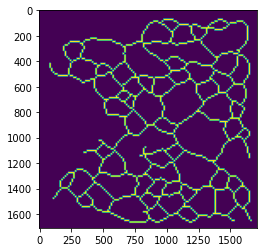

In [1]:
import imageio
import numpy as np
import matplotlib.pyplot as plt

analyzer_skel = imageio.imread('/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/comparison_figures/analyzER-skel/ER_atl1.png')

# analyzer_skel[np.where(analyzer_skel[:,:,0]>0)] = 1

nskel = analyzer_skel[:,:,0].astype(np.uint16)

np.unique(nskel)
# mshow(nskel)

nskel[np.where(nskel==max(np.unique(nskel)))] = 255.

# np.where(nskel > 0)
plt.imshow(nskel)

In [2]:
from skimage.morphology import dilation, remove_small_objects, area_closing, area_opening, erosion, disk

In [10]:
op = dilation(nskel)
for i in range(5):
    op = dilation(op)

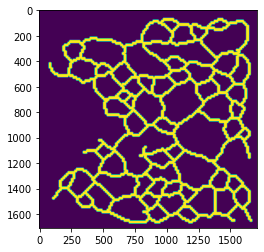

In [11]:
plt.imshow(op)

In [22]:
st = np.zeros((128, 128))

d = []

for i in range(100):
    img = imageio.imread(f'/localhome/asa420/MIAL/data/confocal-data/ATL/std/A3_decon_t0{i:02d}_ch00_std.png')
    st += img
    d.append(img)

# st.shape
st = st / 100

d = np.array(d)
k = np.var(d, axis=0)
k.shape

(128, 128)

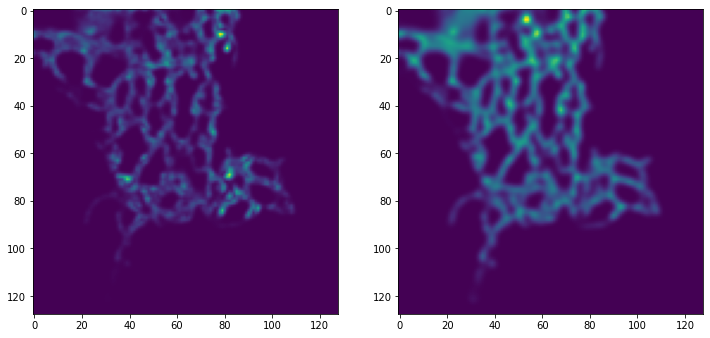

In [24]:

plt.figure(figsize=(12,12))

plt.subplot(121)
plt.imshow(k)

plt.subplot(122)
plt.imshow(st)

In [25]:
from skimage import registration

In [37]:

fldata = []

for i in range(99):
    im1 = imageio.imread(f'/localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t0{i:02d}_ch00_std.png')
    im2 = imageio.imread(f'/localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t0{i+1:02d}_ch00_std.png')

    fl = registration.optical_flow_tvl1(im1, im2)
    fldata.append(fl)

In [40]:
np.array(fldata).shape

(99, 2, 128, 128)

In [44]:
flx = np.array(fldata)[:,0]
fly = np.array(fldata)[:,1]

In [46]:
flx_mean = np.mean(flx, axis=0)

In [47]:
fly_mean = np.mean(fly, axis=0)

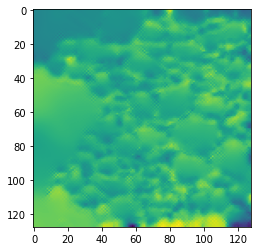

In [48]:
plt.imshow(flx_mean)

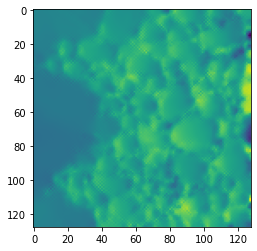

In [49]:
plt.imshow(fly_mean)

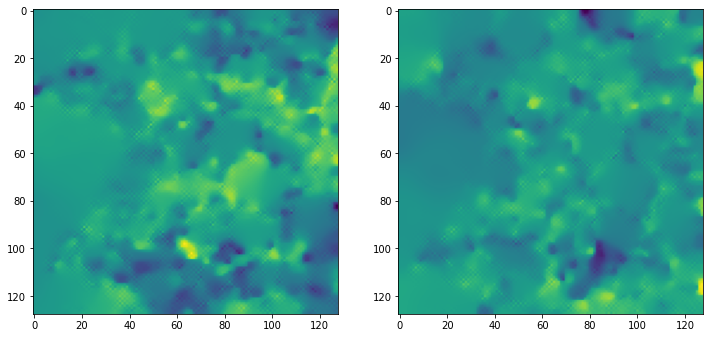

In [33]:

plt.figure(figsize=(12,12))

plt.subplot(121)
plt.imshow(fl[0])

plt.subplot(122)
plt.imshow(fl[1])

In [34]:
phcorr = registration.phase_cross_correlation(im1, im2)

In [36]:
phcorr

(array([0., 0.]), 0.9999999999999999, 0.0)

In [52]:
import os

for i in range(30, 32):
    fname = f'/localhome/asa420/MIAL/data/confocal-data/analyzer_masks/control/ER_c{i}.png'
    os.rename(fname, f'/localhome/asa420/MIAL/data/confocal-data/analyzer_masks/control/ER_control{i}.png')


In [56]:
import shutil
for i in range(1, 30):
    file = f'/localhome/asa420/Downloads/ERnet-v2-main/er-mean/rtn{i}_er_mean_bin.jpg'
    shutil.move(file, '/localhome/asa420/MIAL/data/confocal-data/erv2_masks/')

ModuleNotFoundError: No module named 'monai'

In [61]:
import shutil
for i in range(1, 30):
    img = f'/localhome/asa420/Downloads/ERnet-v2-main/er-mean/rtn{i}_er_mean_out_00{i-1:02d}.png'
    shutil.move(img, f'/localhome/asa420/MIAL/data/confocal-data/erv2_new_masks/rtn/')


In [83]:
for i in range(1, 30):
    img = imageio.imread(f'/localhome/asa420/MIAL/data/confocal-data/erv2_new_masks/rtn/rtn{i}_er_mean_out_00{i-1:02d}.png')
    img[img >= 85] = 255
    imageio.imsave(f'/localhome/asa420/MIAL/data/confocal-data/erv2_new_masks/rtn/rtn{i}_er_mean_out_bin.png', img)

In [78]:
img = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/erv2_new_masks/atl/atl4_er_mean_out_0003.png')
np.unique(img)

Array([  0,  85, 170, 255], dtype=uint8)

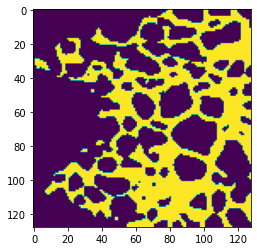

In [75]:
img[img >= 85] = 255
plt.imshow(img)

In [76]:
np.unique(img)

Array([  0, 255], dtype=uint8)

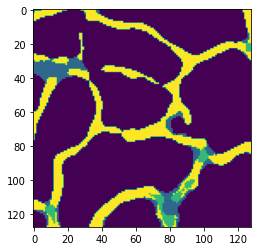

In [92]:
img = imageio.imread('/localhome/asa420/Downloads/ERnet-v2-main/sted_input/sted_climp1_er_mean_out_0033.png')
plt.imshow(img)


In [93]:
np.unique(img)

Array([  0,  85, 170, 255], dtype=uint8)

In [94]:
img[img>=85] = 255.

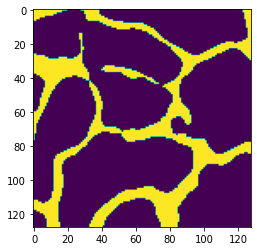

In [95]:
plt.imshow(img)

In [96]:
from skimage.morphology import skeletonize

In [97]:
op = skeletonize(img/255.)

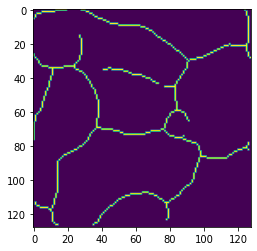

In [98]:
plt.imshow(op)

In [170]:
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
import numpy as np
from skimage import restoration
from skimage.morphology import erosion, skeletonize

class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Mid-level
        self.mid_level = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, out_channels, kernel_size=2, stride=2, output_padding=0)  # Adjusted output_padding
        )

    def forward(self, x):
        # Encoder
        x1 = self.encoder(x)

        # Mid-level
        x2 = self.mid_level(x1)

        # Decoder
        x3 = self.decoder(x2)

        return x3

# Example usage:
in_channels = 1  # Assuming grayscale images
out_channels = 1  # Assuming binary segmentation output

# Adjust the model instantiation
model = UNet(in_channels, out_channels)

model.load_state_dict(torch.load('/localhome/asa420/unet_model.pth'))


for i in range(1, 17):
    try:
        image_path = f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/rtn/images/sted_rtn{i}_er_mean.png'
        image = Image.open(image_path)
        transform = transforms.Compose([
            transforms.ToTensor(),
        ])

        image = transform(image)
        image = image.unsqueeze(0)  # Add batch dimension

        # Forward pass through the model
        model.eval()
        with torch.no_grad():
            output = model(image)

        # Convert the output to probabilities by applying the sigmoid activation
        output_probs = torch.sigmoid(output)
        # Convert tensors to numpy arrays for visualization
        image_np = image.squeeze().numpy()
        output_probs_np = output_probs.cpu().squeeze().numpy()
        norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())
        
#         plt.imshow(norm)
        norm_er = erosion(norm)
        rb = restoration.rolling_ball(norm)

        subt = norm - rb

        subt[subt < 0.1] = 0.
        subt[subt >= 0.1] = 255.

#         plt.imshow(subt)
        imageio.imsave(f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/rtn/nerdynet_op_seg/sted_rtn{i}_er_mean_pred.png', subt)
        
#         plt.imshow(subt)
        
#         subt = erosion(subt/ 255.)
#         plt.imshow(subt)
#         skel = skeletonize(subt)

#         imageio.imsave(f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/climp/nerdynet_op_seg/sted_climp{i}_er_mean_pred_skel.png', skel)
    except:
        pass

Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.


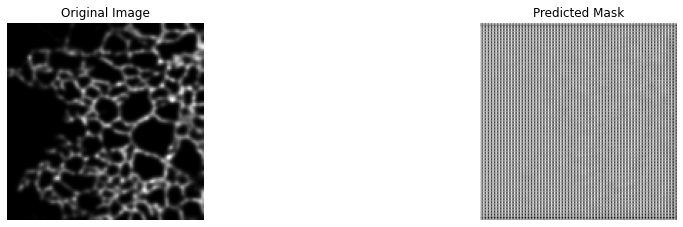

In [129]:
# Load a sample image (replace 'path/to/sample/image.jpg' with your actual image path)
# image_path = '/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/images/atl4_er_mean.png'

image_path = '/localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t043_ch00_std.png'
# mask = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/masks/atl4_er_mean_mask.png')

image = Image.open(image_path)#.convert('L')  # Convert to grayscale
transform = transforms.Compose([
#     transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

image = transform(image)
image = image.unsqueeze(0)  # Add batch dimension

# Forward pass through the model
model.eval()
with torch.no_grad():
    output = model(image)

# Convert the output to probabilities by applying the sigmoid activation
output_probs = torch.sigmoid(output)
type(output_probs)

# Convert tensors to numpy arrays for visualization
image_np = image.squeeze().numpy()
output_probs_np = output_probs.cpu().squeeze().numpy()

# Plot the original image, ground truth mask, and predicted mask
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_np, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# plt.subplot(1, 3, 2)
# plt.imshow(mask, cmap='gray')
# plt.title('Mask')
# plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(output_probs_np, cmap='gray')
plt.title('Predicted Mask')
plt.axis('off')

plt.show()

In [144]:
import glob
files = glob.glob('/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/control/erv2_init/*')

In [145]:
for file in files:
    img = imageio.imread(file)
    img[img>=85] = 255
    fname = '/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/control/erv2_op/' + file.split('/')[-1].split('.')[0] + '_bin.png'
    imageio.imsave(fname, img)

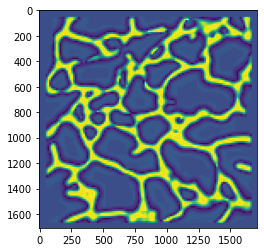

In [157]:
analyzer_enh = imageio.imread('comparison_figures/processed data/images/ER_enh.png')

# print(analyzer_enh.shape)

a = analyzer_enh[:,:,0]
b = analyzer_enh[:,:,1]
c = analyzer_enh[:,:,2]

plt.imshow(analyzer_enh[:,:,0])

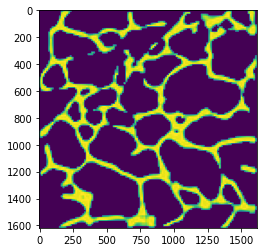

In [163]:
plt.imshow(a[52:1670, 52:1670])

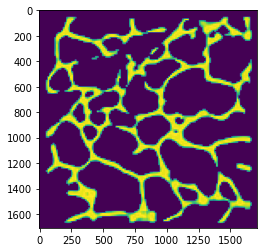

In [160]:
thra = threshold_otsu(a)

na = a
na[a<thra] = 0

plt.imshow(na)

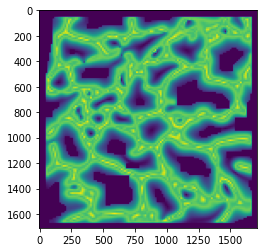

In [147]:
plt.imshow(analyzer_enh[:,:,1])

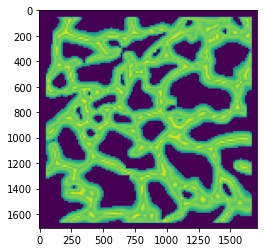

In [161]:
thrb = threshold_otsu(b)

nb = b
nb[b < thrb] = 0

plt.imshow(nb)

In [148]:
beads = analyzer_enh[:,:,1] - analyzer_enh[:,:,0]

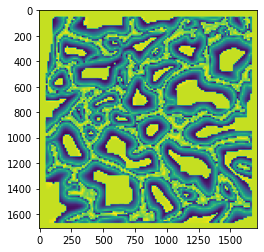

In [149]:
plt.imshow(beads)

In [150]:
beads = beads - analyzer_enh[:,:,2]

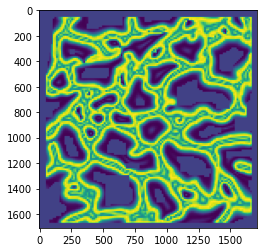

In [151]:
plt.imshow(beads)

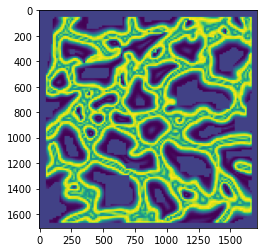

In [155]:
from skimage.filters import threshold_otsu, threshold_local
thr = threshold_otsu(beads)

# plt.imshow(beads > thr)
plt.imshow(threshold_local(beads))

In [156]:
np.unique(analyzer_enh[:,:,0])

Array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [167]:
prefix = '/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/'
method_name = {'gt': 'masks','analyzer': 'analyzer_op', 'erv2': 'erv2_op', 'ernet': 'ernet_op', 'nerdy': 'nerdy_op', 'nerdynet': 'nerdynet_op'}
method = 'gt'

In [ ]:
import os
groups = ['climp', 'control', 'rtn']

for group in groups:
    fn = f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/{group}/analyzer_op/ER_cte2.png'
